# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [1]:
ПІБ = 'Левченко Денис'
ГРУПА = 'ШІ-33'
ВАРІАНТ = 4

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [2]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
ПОТІК = ПОТОКИ[(i * 3 + 1) % 8]
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Левченко Денис, ШІ-33, варіант 4
ваш потік:                   P>100
ваша пара для графіка 3:     радіопотік F10.7 та швидкість вітру
ваш агрегат для етапу 4:     максимум
ваше додаткове питання:      Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [4]:
df = pd.read_excel(ФАЙЛ)
print('розмір:', df.shape)
print(df.dtypes.value_counts())
df.head()

розмір: (7225, 32)
object     24
float64     8
Name: count, dtype: int64


,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** Коли pandas читає файл бере перший рядок як назви стовпців. Але в першому рядку майже все порожнє, тільки два посилання. Тому стовпці називаються `Unnamed`, а типи виходять `object`, бо в стовпцях перемішані текст (опис зверху) і числа. Рядків 7225, а не 7226, бо один рядок пішов у назви.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [5]:
RAW = pd.read_excel(ФАЙЛ, header=None)
print('розмір:', RAW.shape)
RAW.head(30)

розмір: (7226, 32)


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [6]:
print(RAW.notna().sum())

0        0
1     7223
2     7202
3     7202
4     7202
5     7203
6     7203
7     7198
8     7198
9     7198
10    7198
11    7198
12    7198
13    7198
14    7198
15       0
16      32
17      26
18      26
19      26
20       0
21       0
22       0
23       0
24     601
25     601
26     608
27     602
28     602
29     602
30     602
31     602
dtype: int64


**Відповідь 1.3:** Порахував заповнені клітинки в кожному стовпці. Видно три групи стовпців з великими числами — це три таблиці: A це стовпці 1–14, B це 16–19, C це 24–31. Між ними стовпці з нулями — порожні. Числа всередині однієї таблиці трохи різні, бо зверху ще є рядки тексту-опису.

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [7]:
# текст-опис лежить у стовпцях 1 (таблиця A), 16 (B) і 26 (C)
for номер in [1, 16, 26]:
    print('===== стовпець', номер, '=====')
    for значення in RAW[номер]:
        if isinstance(значення, str):   
            print(значення)
    print()

===== стовпець 1 =====
ftp://ftp.swpc.noaa.gov/pub/lists/particle/
:Data_list: 20170901_Gs_part_5m.txt
:Created: 2017 Sep 02 0011 UTC
# Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
# Please send comments and suggestions to SWPC.Webmaster@noaa.gov 
# 
# Label: P > 1 = Particles at >1 Mev
# Label: P > 5 = Particles at >5 Mev
# Label: P >10 = Particles at >10 Mev
# Label: P >30 = Particles at >30 Mev
# Label: P >50 = Particles at >50 Mev
# Label: P>100 = Particles at >100 Mev
# Label: E>0.8 = Electrons at >0.8 Mev
# Label: E>2.0 = Electrons at >2.0 Mev
# Label: E>4.0 = Electrons at >4.0 Mev
# Units: Particles = Protons/cm2-s-sr
# Units: Electrons = Electrons/cm2-s-sr
# Source: GOES-15
# Location: W135
# Missing data: -1.00e+05
5-minute  GOES-15 Solar Particle and Electron Flux
# UT
# YR

===== стовпець 16 =====
ftp://ftp.swpc.noaa.gov/pub/indices/old_indices/2017Q3_DSD.txt
Product: Daily Solar Data         quar_DSD.txt
:Issued: 0825 UT 04 Oct 2017
#
#  Pre

**Відповідь 1.4:**

| Таблиця | Джерело | Одиниці |
|---|---|---|
| A | NOAA SWPC, супутник GOES-15, 5-хвилинні дані | частинок/(см²·с·ср); позначка "немає даних" = −1.00e+05 |
| B | NOAA SWPC, добові дані F10.7 | одиниці не вказані; за довідкою це sfu |
| C | SOHO CELIAS, погодинний сонячний вітер | швидкість — км/с, густина — протонів/см³ |

Дивне: в описі A є потік E>4.0, але такого стовпця нема; в описі C названо більше стовпців, ніж є насправді.

---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [8]:
A = RAW.iloc[26:7226, 1:15].copy()
A.columns = ['рік', 'місяць', 'день', 'ггхх', 'MJD', 'секунда_доби',
             'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

B = RAW.iloc[27:52, 16:20].copy()
B.columns = ['рік', 'місяць', 'день', 'F10.7']

# стовпці 24 і 25 (Y, Z) пропускаю — це копії години, беру з 26
C = RAW.iloc[27:628, 26:32].copy()
C.columns = ['рік', 'місяць', 'день', 'година', 'швидкість', 'густина']

A = A.apply(pd.to_numeric, errors='coerce').reset_index(drop=True)
B = B.apply(pd.to_numeric, errors='coerce').reset_index(drop=True)
C = C.apply(pd.to_numeric, errors='coerce').reset_index(drop=True)

print(A.shape, B.shape, C.shape)

(7200, 14) (25, 4) (601, 6)


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [9]:
A['ts'] = pd.to_datetime(dict(year=A['рік'], month=A['місяць'], day=A['день'],
                              hour=A['ггхх'] // 100, minute=A['ггхх'] % 100))
B['ts'] = pd.to_datetime(dict(year=B['рік'], month=B['місяць'], day=B['день']))
C['ts'] = pd.to_datetime(dict(year=C['рік'] + 2000, month=C['місяць'],
                              day=C['день'], hour=C['година']))

print('A:', A['ts'].min(), '-', A['ts'].max())
print('B:', B['ts'].min(), '-', B['ts'].max())
print('C:', C['ts'].min(), '-', C['ts'].max())

A: 2017-08-28 00:00:00 - 2017-09-21 23:55:00
B: 2017-08-28 00:00:00 - 2017-09-21 00:00:00
C: 2017-08-28 00:00:00 - 2017-09-22 00:00:00


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [10]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [11]:
for назва, таблиця in [('A', A), ('B', B), ('C', C)]:
    print('==============', назва, '==============')
    print('розмір:', таблиця.shape)
    print('дублікатів рядків:', таблиця.duplicated().sum())
    print('пропуски по стовпцях:')
    print(таблиця.isna().sum())
    print(таблиця.describe())
    print()

print('рядки A, де мій потік порожній:')
print(A[A['P>100'].isna()])

============== A ==============
розмір: (7200, 15)
дублікатів рядків: 0
пропуски по стовпцях:
рік             0
місяць          0
день            0
ггхх            0
MJD             0
секунда_доби    0
P>1             3
P>5             3
P>10            3
P>30            3
P>50            3
P>100           3
E>0.8           3
E>2.0           3
ts              0
dtype: int64
          рік       місяць         день         ггхх           MJD  \
count  7200.0  7200.000000  7200.000000  7200.000000   7200.000000   
mean   2017.0     8.840000    13.960000  1177.500000  58005.000000   
min    2017.0     8.000000     1.000000     0.000000  57993.000000   
25%    2017.0     9.000000     7.000000   588.750000  57999.000000   
50%    2017.0     9.000000    13.000000  1177.500000  58005.000000   
75%    2017.0     9.000000    19.000000  1766.250000  58011.000000   
max    2017.0     9.000000    31.000000  2355.000000  58017.000000   
std       0.0     0.366632     8.775483   692.481902      7.211

### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [12]:
print('від\'ємних у швидкості:', (C['швидкість'] < 0).sum())
print('від\'ємних у густині: ', (C['густина'] < 0).sum())
print(C[C['швидкість'] < 0][['ts', 'швидкість', 'густина']])

print('до заміни:  швидкість mean =', round(C['швидкість'].mean(), 2), ' min =', C['швидкість'].min())
print('            густина   mean =', round(C['густина'].mean(), 2), ' min =', C['густина'].min())

C.loc[C['швидкість'] < 0, 'швидкість'] = np.nan
C.loc[C['густина'] < 0, 'густина'] = np.nan

print('після заміни: швидкість mean =', round(C['швидкість'].mean(), 2), ' min =', C['швидкість'].min())
print('              густина   mean =', round(C['густина'].mean(), 2), ' min =', C['густина'].min())

від'ємних у швидкості: 8
від'ємних у густині:  8
                     ts  швидкість  густина
175 2017-09-04 07:00:00         -1     -1.0
176 2017-09-04 08:00:00         -1     -1.0
177 2017-09-04 09:00:00         -1     -1.0
178 2017-09-04 10:00:00         -1     -1.0
179 2017-09-04 11:00:00         -1     -1.0
180 2017-09-04 12:00:00         -1     -1.0
181 2017-09-04 13:00:00         -1     -1.0
182 2017-09-04 14:00:00         -1     -1.0
до заміни:  швидкість mean = 506.55  min = -1
            густина   mean = 2.91  min = -1.0
після заміни: швидкість mean = 513.39  min = 277.0
              густина   mean = 2.96  min = 0.1


**Відповідь 3.2:** У швидкості й густині є значення −1, по 8 штук, усі 4 вересня з 07:00 до 14:00 підряд. Швидкість і густина не бувають від'ємні. Замінив їх на NaN. Після заміни середня швидкість стала 513.4 замість 506.5, а мінімум 277 замість −1.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [13]:
print(A[['рік', 'місяць', 'день', 'ггхх', 'MJD', 'секунда_доби']].describe())

          рік       місяць         день         ггхх           MJD  \
count  7200.0  7200.000000  7200.000000  7200.000000   7200.000000   
mean   2017.0     8.840000    13.960000  1177.500000  58005.000000   
std       0.0     0.366632     8.775483   692.481902      7.211603   
min    2017.0     8.000000     1.000000     0.000000  57993.000000   
25%    2017.0     9.000000     7.000000   588.750000  57999.000000   
50%    2017.0     9.000000    13.000000  1177.500000  58005.000000   
75%    2017.0     9.000000    19.000000  1766.250000  58011.000000   
max    2017.0     9.000000    31.000000  2355.000000  58017.000000   

       секунда_доби  
count   7200.000000  
mean   43050.000000  
std    24943.113498  
min        0.000000  
25%    21525.000000  
50%    43050.000000  
75%    64575.000000  
max    86100.000000  


**Відповідь 3.3:** Середнє не має сенсу для стовпців `рік`, `місяць`, `день`, `ггхх`, `MJD`, `секунда_доби`. Це не виміри, а час. Наприклад "середній день 13.96" — це просто середина між серпнем і вереснем, вона нічого не означає. А `ггхх` це взагалі просто запис часу числом.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [14]:
A_index = A.set_index('ts')
потоки = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

A_mean = A_index[потоки].resample('h').mean()
A_max = A_index[потоки].resample('h').max()

A_mean.columns = [назва + ' mean' for назва in потоки]
A_max.columns = [назва + ' max' for назва in потоки]

A_год = A_mean.join(A_max).reset_index()
print(A_год.shape)
A_год.head()

(600, 17)


,ts,P>1 mean,P>5 mean,P>10 mean,P>30 mean,P>50 mean,P>100 mean,E>0.8 mean,E>2.0 mean,P>1 max,P>5 max,P>10 max,P>30 max,P>50 max,P>100 max,E>0.8 max,E>2.0 max
0,2017-08-28 00:00:00,9.778333,0.324917,0.192917,0.098850,0.077583,0.040692,20941.666667,1011.583333,19.40,0.690,0.314,0.2240,0.1780,0.0793,23600.0,1180.0
1,2017-08-28 01:00:00,7.994167,0.291667,0.156583,0.072583,0.058700,0.029950,18091.666667,713.000000,13.60,0.512,0.259,0.0919,0.0798,0.0471,20600.0,907.0
2,2017-08-28 02:00:00,6.099167,0.283000,0.177667,0.084450,0.069642,0.035025,14108.333333,380.833333,10.80,0.479,0.321,0.1210,0.1110,0.0595,15000.0,475.0
3,2017-08-28 03:00:00,4.752500,0.236833,0.166333,0.087658,0.068092,0.035517,12766.666667,267.916667,7.76,0.329,0.244,0.1800,0.1390,0.0818,13100.0,284.0
4,2017-08-28 04:00:00,4.158333,0.334917,0.208333,0.084800,0.072850,0.039708,11333.333333,203.000000,6.62,0.539,0.309,0.1530,0.1420,0.0694,12300.0,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

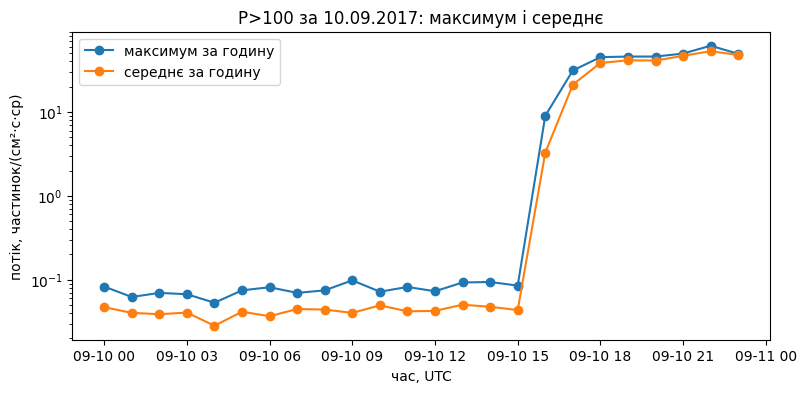

                     максимум  середнє
ts                                    
2017-09-10 00:00:00      0.08     0.05
2017-09-10 01:00:00      0.06     0.04
2017-09-10 02:00:00      0.07     0.04
2017-09-10 03:00:00      0.07     0.04
2017-09-10 04:00:00      0.05     0.03
2017-09-10 05:00:00      0.07     0.04
2017-09-10 06:00:00      0.08     0.04
2017-09-10 07:00:00      0.07     0.04
2017-09-10 08:00:00      0.07     0.04
2017-09-10 09:00:00      0.10     0.04
2017-09-10 10:00:00      0.07     0.05
2017-09-10 11:00:00      0.08     0.04
2017-09-10 12:00:00      0.07     0.04
2017-09-10 13:00:00      0.09     0.05
2017-09-10 14:00:00      0.09     0.05
2017-09-10 15:00:00      0.09     0.04
2017-09-10 16:00:00      8.99     3.27
2017-09-10 17:00:00     31.20    21.13
2017-09-10 18:00:00     44.90    38.32
2017-09-10 19:00:00     45.70    41.20
2017-09-10 20:00:00     45.70    40.91
2017-09-10 21:00:00     49.60    46.61
2017-09-10 22:00:00     61.50    52.93
2017-09-10 23:00:00     4

In [15]:
день = A[(A['ts'] >= '2017-09-10') & (A['ts'] < '2017-09-11')]
день = день.set_index('ts')
макс = день[ПОТІК].resample('h').max()
сер = день[ПОТІК].resample('h').mean()

plt.figure(figsize=(9, 4))
plt.plot(макс.index, макс, marker='o', label='максимум за годину')
plt.plot(сер.index, сер, marker='o', label='середнє за годину')
plt.yscale('log')
plt.title(ПОТІК + ' за 10.09.2017: максимум і середнє')
plt.xlabel('час, UTC')
plt.ylabel('потік, частинок/(см²·с·ср)')
plt.legend()
plt.show()

таблиця = pd.DataFrame({'максимум': макс.round(2), 'середнє': сер.round(2)})
print(таблиця)

**Відповідь 4.2:** Максимум завжди більший або рівний середньому. Поки тихо (до 16:00) вони майже однакові. Коли о 16:00 почалась буря, максимум став 8.99, а середнє тільки 3.27 — середнє "згладжує" різкий стрибок. Значить максимум краще показує різкі зміни.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [16]:
C_потрібне = C[['ts', 'швидкість', 'густина']]

inner = A_год.merge(C_потрібне, on='ts', how='inner')
outer = A_год.merge(C_потрібне, on='ts', how='outer')
print('inner:', len(inner), 'рядків')
print('outer:', len(outer), 'рядків')

M = inner.copy()   # беру inner

# F10.7 один на добу, тому додаю стовпець доба і приєдную по ньому
M['доба'] = M['ts'].dt.floor('D')
B_доби = B[['ts', 'F10.7']].rename(columns={'ts': 'доба'})
M = M.merge(B_доби, on='доба', how='left')

print('M:', M.shape)
print('рядки з пропусками:')
print(M[M.isna().any(axis=1)])

inner: 600 рядків
outer: 601 рядків
M: (600, 21)
рядки з пропусками:
                     ts  P>1 mean  P>5 mean  P>10 mean  P>30 mean  P>50 mean  \
175 2017-09-04 07:00:00  6.465833  0.262083   0.171500   0.085483   0.068558   
176 2017-09-04 08:00:00  4.010833  0.256000   0.195833   0.086625   0.070033   
177 2017-09-04 09:00:00  3.268333  0.303417   0.220333   0.105925   0.081975   
178 2017-09-04 10:00:00  3.179167  0.252167   0.181833   0.101900   0.081675   
179 2017-09-04 11:00:00  5.274167  0.295083   0.186917   0.089525   0.063983   
180 2017-09-04 12:00:00  2.965000  0.217750   0.153500   0.089217   0.071217   
181 2017-09-04 13:00:00  3.061667  0.275833   0.192833   0.104542   0.083783   
182 2017-09-04 14:00:00  7.279167  0.231333   0.170583   0.086508   0.070667   

     P>100 mean    E>0.8 mean   E>2.0 mean  P>1 max  ...  P>10 max  P>30 max  \
175    0.031717  90600.000000  7410.833333    10.10  ...     0.294     0.145   
176    0.036492  73483.333333  5048.333333     5.0

**Відповідь 4.3:** `inner` дав 600 рядків, `outer` — 601. Зайвий рядок в outer це 22 вересня: там є тільки швидкість і густина, а потоків нема, бо таблиця C на годину довша за A. Тому взяв `inner`. F10.7 приєднав по добі, бо він один на цілий день.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [17]:
M['група'] = pd.cut(M['P>10 max'],
                    bins=[-np.inf, 10, 1000, np.inf],
                    right=False,
                    labels=['тиха', 'активна', 'дуже активна'])
print(M['група'].value_counts(sort=False))

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


**Самоперевірка етапу 4.**

In [18]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

середнє = 1.66
медіана = 0.04
годин з потоком менше 1: 547 з 600
60 найбільших годин дають 97 % суми


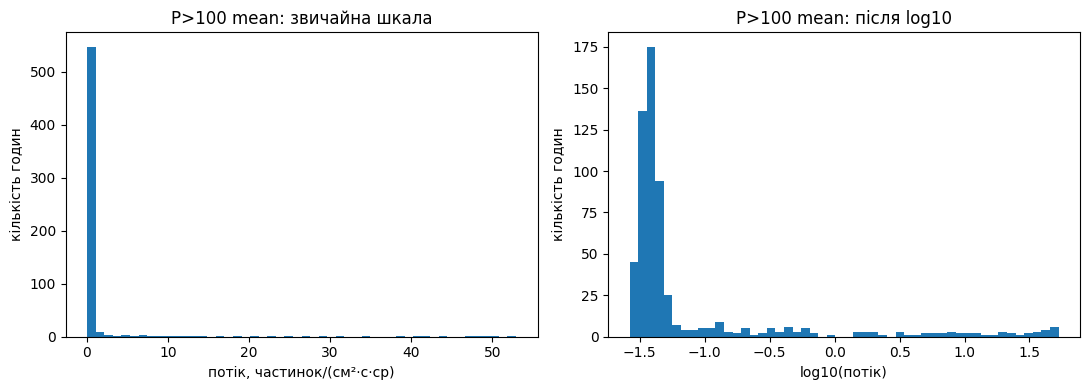

In [19]:
x = M[ПОТІК + ' mean']
print('середнє =', round(x.mean(), 2))
print('медіана =', round(x.median(), 2))
print('годин з потоком менше 1:', (x < 1).sum(), 'з', len(x))
найбільші = x.sort_values(ascending=False)
print('60 найбільших годин дають', round(найбільші.head(60).sum() / x.sum() * 100), '% суми')

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.hist(x, bins=50)
plt.title(ПОТІК + ' mean: звичайна шкала')
plt.xlabel('потік, частинок/(см²·с·ср)')
plt.ylabel('кількість годин')

plt.subplot(1, 2, 2)
plt.hist(np.log10(x), bins=50)
plt.title(ПОТІК + ' mean: після log10')
plt.xlabel('log10(потік)')
plt.ylabel('кількість годин')

plt.tight_layout()
plt.show()

**Висновок:** Майже всі години потік маленький, близько 0.04. Великий він тільки під час бурі. Тому середнє (1.66) набагато більше за медіану (0.04) — його тягнуть кілька великих значень.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

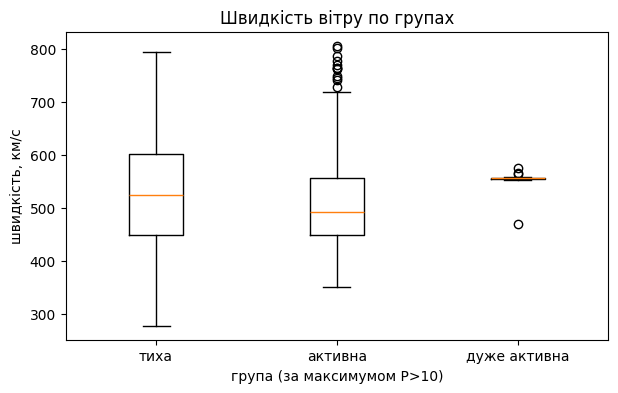

медіана швидкості:
тиха: 524
активна: 492
дуже активна: 556


In [20]:
тиха = M[M['група'] == 'тиха']['швидкість'].dropna()
активна = M[M['група'] == 'активна']['швидкість'].dropna()
дуже = M[M['група'] == 'дуже активна']['швидкість'].dropna()

plt.figure(figsize=(7, 4))
plt.boxplot([тиха, активна, дуже])
plt.xticks([1, 2, 3], ['тиха', 'активна', 'дуже активна'])
plt.title('Швидкість вітру по групах')
plt.xlabel('група (за максимумом P>10)')
plt.ylabel('швидкість, км/с')
plt.show()

print('медіана швидкості:')
print('тиха:', round(тиха.median()))
print('активна:', round(активна.median()))
print('дуже активна:', round(дуже.median()))

**Висновок:** Швидкість вітру приблизно однакова в усіх групах, медіани близькі (524, 492, 556). Явної різниці нема. У "дуже активної" коробка вузька, бо це всього 18 годин одного дня.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

Пірсон: 0.06
точок: 592


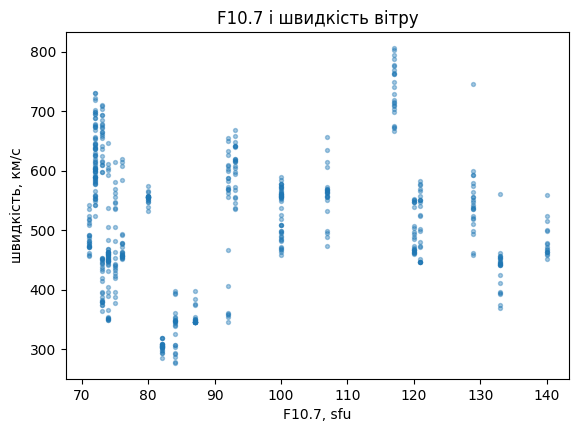

In [21]:
пара = M[['F10.7', 'швидкість']].dropna()
print('Пірсон:', round(пара['F10.7'].corr(пара['швидкість']), 2))
print('точок:', len(пара))

plt.figure(figsize=(6.5, 4.5))
plt.scatter(пара['F10.7'], пара['швидкість'], s=8, alpha=0.4)
plt.title('F10.7 і швидкість вітру')
plt.xlabel('F10.7, sfu')
plt.ylabel('швидкість, км/с')
plt.show()

**Висновок:** Точки розкидані хаотично, кореляція 0.06 — це майже нуль. F10.7 і швидкість вітру не пов'язані. Точок ніби багато (592), але F10.7 однаковий цілу добу, тому насправді різних значень тільки 25.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

група
тиха            411
активна         171
дуже активна     18
Name: count, dtype: int64


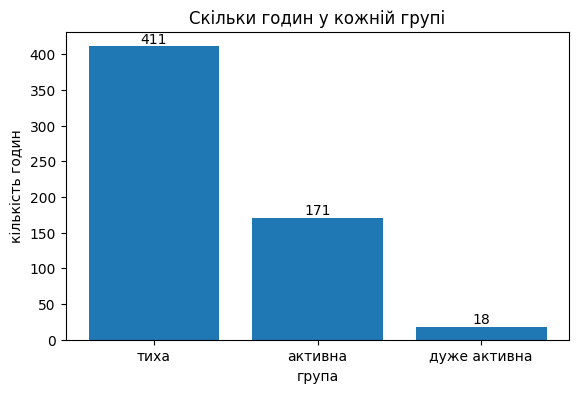

тиха : 411 годин = 68.5 %
активна : 171 годин = 28.5 %
дуже активна : 18 годин = 3.0 %


In [22]:
кількість = M['група'].value_counts(sort=False)
print(кількість)

plt.figure(figsize=(6.5, 4))
plt.bar(['тиха', 'активна', 'дуже активна'], кількість.values)
for i in range(3):
    plt.text(i, кількість.values[i], str(кількість.values[i]), ha='center', va='bottom')
plt.title('Скільки годин у кожній групі')
plt.xlabel('група')
plt.ylabel('кількість годин')
plt.show()

всього = кількість.sum()
for назва in ['тиха', 'активна', 'дуже активна']:
    print(назва, ':', кількість[назва], 'годин =', round(кількість[назва] / всього * 100, 1), '%')

**Висновок:** Більшість часу тихо — 411 годин (68.5%). Активних 171 (28.5%), дуже активних 18 (3%). Неспокійні години зібрані у двох періодах: 5–8 і 10–14 вересня.

### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

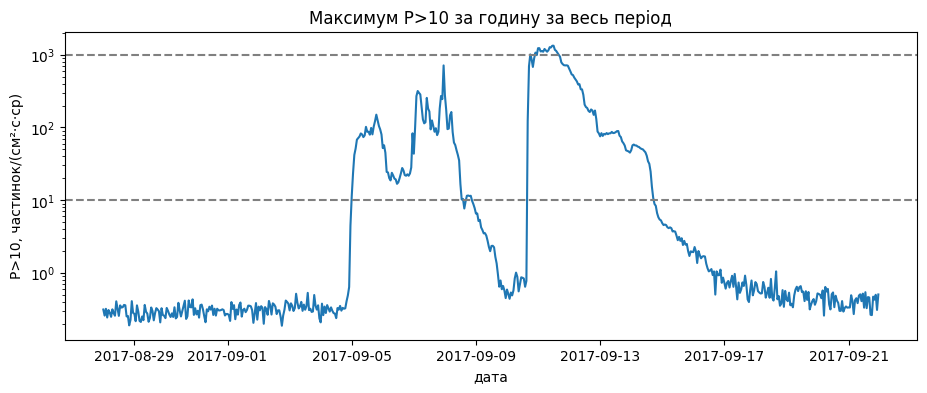

пік: 1330.0  медіана: 0.64


In [23]:
plt.figure(figsize=(11, 4))
plt.plot(M['ts'], M['P>10 max'])
plt.yscale('log')
plt.axhline(10, color='gray', linestyle='--')
plt.axhline(1000, color='gray', linestyle='--')
plt.title('Максимум P>10 за годину за весь період')
plt.xlabel('дата')
plt.ylabel('P>10, частинок/(см²·с·ср)')
plt.show()

print('пік:', M['P>10 max'].max(), ' медіана:', round(M['P>10 max'].median(), 2))

**Висновок:** За весь час було дві бурі: 5–8 і 10–14 вересня. Потік P>10 піднімався до 713 і 1330, а звичайно він близько 0.3. Різниця у тисячі разів, тому шкала логарифмічна.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

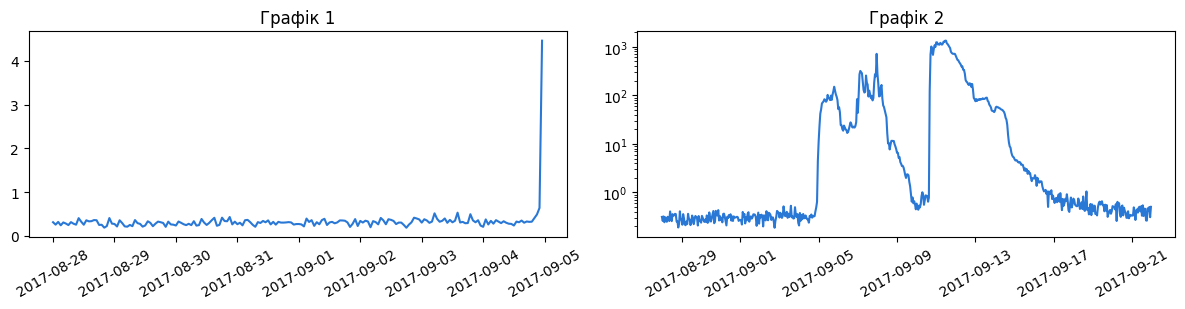

In [24]:
СТОВПЕЦЬ = 'P>10 max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка: все спокійно і 5 числа щось почалося.
2. Висновок з другого графіка: були дуже сильні бурі.
3. Дві відмінності: перший графік показує тільки початок (до 5 вересня) і має звичайну шкалу, а другий — весь період і логарифмічну шкалу.

### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

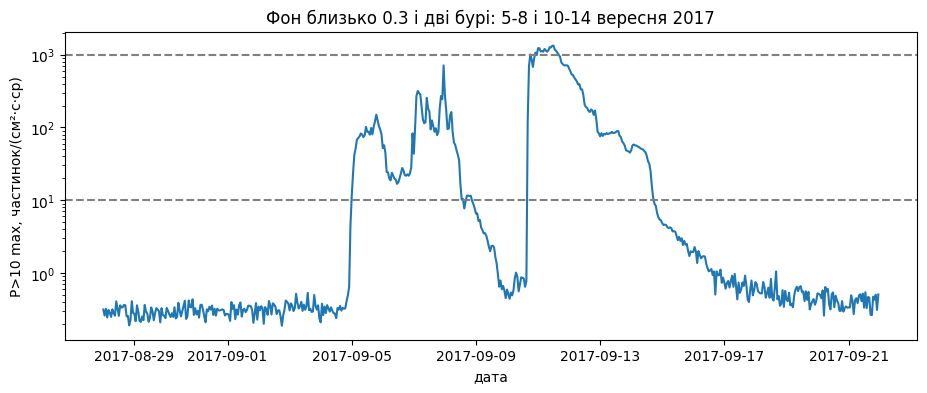

In [25]:
plt.figure(figsize=(11, 4))
plt.plot(M['ts'], M['P>10 max'])
plt.yscale('log')
plt.axhline(10, color='gray', linestyle='--')
plt.axhline(1000, color='gray', linestyle='--')
plt.title('Фон близько 0.3 і дві бурі: 5-8 і 10-14 вересня 2017')
plt.xlabel('дата')
plt.ylabel('P>10 max, частинок/(см²·с·ср)')
plt.show()

**Відповідь 6.2:** Я взяв весь період, щоб було видно обидві бурі, і логарифмічну шкалу, бо числа дуже різні (від 0.19 до 1330). Додав лінії порогів 10 і 1000 та підписав осі. У заголовку одразу написав висновок.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** Перша буря (5–8 вересня) майже не підняла мій потік P>100 — максимум був 0.41. А друга буря 10 вересня підняла його аж до 61.5. Видно в таблиці добових максимумів (клітинка 7.2) і на графіку 5.

**Спостереження 2:** Середнє P>100 у багато разів більше за медіану, бо 91% годин потік маленький, а кілька годин бурі — дуже великі. Видно на графіку 1.

**Спостереження 3:** F10.7 був найбільший 4 вересня, ще до бур, а під час найсильнішої бурі був малий. Значить F10.7 не пов'язаний з бурями. Видно в таблиці B і на графіку 3.

### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [26]:
активні_доби = M[M['група'] == 'активна']['доба'].nunique()
дуже_доби = M[M['група'] == 'дуже активна']['доба'].nunique()
print('активна: різних діб =', активні_доби)
print('дуже активна: різних діб =', дуже_доби)

print('активні доби:', M[M['група'] == 'активна']['доба'].dt.strftime('%d.%m').unique())
print('дуже активні доби:', M[M['група'] == 'дуже активна']['доба'].dt.strftime('%d.%m').unique())

# для спостереження 1: добові максимуми P>10 і P>100
print('добові максимуми:')
print(M.groupby('доба')[['P>10 max', 'P>100 max']].max())

активна: різних діб = 9
дуже активна: різних діб = 2
активні доби: ['05.09' '06.09' '07.09' '08.09' '10.09' '11.09' '12.09' '13.09' '14.09']
дуже активні доби: ['10.09' '11.09']
добові максимуми:
            P>10 max  P>100 max
доба                           
2017-08-28     0.409     0.0856
2017-08-29     0.363     0.0879
2017-08-30     0.433     0.0829
2017-08-31     0.367     0.1080
2017-09-01     0.397     0.0988
2017-09-02     0.417     0.1100
2017-09-03     0.532     0.0885
2017-09-04     4.460     0.0998
2017-09-05   150.000     0.1160
2017-09-06    83.100     0.4060
2017-09-07   713.000     0.1480
2017-09-08   279.000     0.1230
2017-09-09     6.570     0.0913
2017-09-10  1070.000    61.5000
2017-09-11  1330.000    51.7000
2017-09-12   648.000     7.6900
2017-09-13    89.300     0.6890
2017-09-14    58.200     0.2390
2017-09-15     4.830     0.0941
2017-09-16     2.270     0.1070
2017-09-17     0.969     0.0884
2017-09-18     1.050     0.0987
2017-09-19     0.658     0.0915
2017

**Відповідь 7.2:** У групу "активна" попало 9 різних діб (5–8 і 10–14 вересня), у "дуже активна" — 2 доби (10 і 11 вересня). Рахував так: якщо в добі є хоч одна година такої групи, то доба туди рахується.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [27]:
ІНСТРУМЕНТИ_ШІ = 'Claude'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1–2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення':     'код, перевірено',
    'етап 4, об’єднання таблиць':                 'код, перевірено',
    'етап 5, побудова графіків':                  'код, перевірено',
    'етап 5, формулювання висновків':             'текст, перероблено',
    'етапи 6–7, порівняння графіків і спостереження': 'текст, перероблено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'Перевірив числа в побудованих графіках. Передивився та перевірив все дивне що було знайдено в Excel; Перевірив формули в коді. Знайшов помилку в захардкодженому потоці нейромережею(і якщо би я змінював варіант то треба було б в завданні також змінювати) і було добавлено потік на самий початок коли його визначають для вас.'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True 

In [28]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Левченко Денис
інструменти:                                   Claude
------------------------------------------------------------------------------
етапи 1–2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        код, перевірено
етап 4, об’єднання таблиць:                    код, перевірено
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6–7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Перевірив числа в побудованих графіках. Передивився та перевірив все дивне що було знайдено в Excel; Перевірив формули в коді. Знайшов помилку в захардкодженому потоці нейромережею(і якщо би я змінював варіант то треба було б в завданні також змінювати) і було добавлено потік на сам

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [29]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 22)


In [30]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
